<a href="https://colab.research.google.com/github/sidnb13/moonshots/blob/master/linapprox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import random
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import make_classification
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

seed = 42

np.random.seed(seed)
random.seed(seed)

In [2]:
# train an extremely simple N layer classifier on some synthetic data
# Generate some counterfactuals which result from input perturbations
# We can intervene on some layer for ground truth
# And check if approximationg gives us a roughly equivalent result after logit-biasing
n_features = 32
n_classes = 4

X, y = make_classification(
    n_samples=20_000,
    n_features=n_features,
    n_informative=n_features,
    n_redundant=0,
    n_classes=n_classes, # so we can have "wrong" choices
    flip_y=0.01,
    random_state=seed
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10_000, shuffle=True
)

X_test, X_exp, y_test, y_exp = train_test_split(
    X_test, y_test, test_size=1000
)

class ClsDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __getitem__(self, index) -> dict:
        return {
            "x": torch.tensor(self.X[index], dtype=torch.float32),
            "y": torch.tensor(self.y[index], dtype=torch.long)
        }

    def __len__(self):
        return len(self.X)

bsz = 64

train_ds = ClsDataset(X_train, y_train)
train_dl = DataLoader(
    train_ds,
    bsz,
    shuffle=True
)
test_ds = ClsDataset(X_test, y_test)
test_dl = DataLoader(
    test_ds,
    bsz
)

In [3]:
from itertools import cycle
from tqdm import tqdm

# train a simple classifier
class Classifier(nn.Module):
    def __init__(self, n_layers, n_features, n_dim, n_classes):
        super().__init__()
        layers = []
        in_d,out_d = n_features, n_dim
        for _ in range(n_layers):
            layers.extend([nn.Linear(
                in_d,out_d
            ), nn.ReLU()])
            in_d, out_d = out_d, n_dim
        self.stack = nn.Sequential(*layers)
        self.head = nn.Linear(out_d, n_classes)

    def forward(self,x):
        return self.head(self.stack(x))

# loop
model = Classifier(4, n_features, n_features * 2, n_classes).cuda()
opt = torch.optim.SGD(model.parameters(), lr=1e-2)
criterion = nn.CrossEntropyLoss()

train_steps = 10_000

step = 0
for batch in tqdm(cycle(train_dl), total=train_steps):
    if step > train_steps:
        break
    logits = model(batch["x"].cuda())
    loss = criterion(logits, batch["y"].cuda())

    opt.zero_grad()
    loss.backward()
    opt.step()
    step += 1

# test
with torch.no_grad():
    total_loss = 0
    correct = 0
    for batch in iter(test_dl):
        x,y = batch["x"].cuda(), batch["y"].cuda()
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item()
        correct += (logits.argmax(-1) == y).sum().item()

acc = correct / len(X_test)
avg_loss = total_loss / len(X_test)
print(f"{acc=}, {avg_loss=}")

10001it [00:16, 616.63it/s]                          


acc=0.9221111111111111, avg_loss=0.00481443798997336


In [4]:
model = model.cuda()

In [5]:
model

Classifier(
  (stack): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): ReLU()
  )
  (head): Linear(in_features=64, out_features=4, bias=True)
)

In [6]:
INTERVENE_MODULE = model.stack[3]

In [7]:
import torch
from tqdm import tqdm

def find_counterfactual(model, x, y, iters=10, lr=1e-2, temp=0.5, lam1=0.1, lam2=0.1):
    """Optimized gradient-based counterfactual search using tensor bookkeeping"""

    # Freeze model
    for p in model.parameters():
        p.requires_grad_(False)

    x_tensor = torch.from_numpy(x).cuda().to(torch.float32).requires_grad_(False)
    y_tensor = torch.from_numpy(y).cuda().to(torch.long)

    mu, std = x_tensor.mean(), x_tensor.std()

    param = torch.randn_like(x_tensor).requires_grad_(True)
    opt = torch.optim.SGD([param], lr=lr)

    # Tensor bookkeeping - track which indices have found CFs
    found_cf = torch.zeros(len(x), dtype=torch.bool, device='cuda')
    cf_inputs = torch.zeros_like(x_tensor)
    cf_preds = torch.zeros_like(y_tensor)

    pbar = tqdm(range(iters))

    for _ in pbar:
        perturbed = x_tensor + param
        logits = model(perturbed)
        loss = (lam1 * torch.norm(perturbed - x_tensor)
                - torch.nn.functional.cross_entropy(logits, y_tensor)
                + lam2 * torch.norm(param, p=1)).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        with torch.no_grad():
            preds = model(perturbed).argmax(-1)
            cf_correct = (preds != y_tensor)

            # Update bookkeeping only for newly found CFs
            new_cfs = cf_correct & ~found_cf
            if new_cfs.any():
                cf_inputs[new_cfs] = perturbed[new_cfs]
                cf_preds[new_cfs] = preds[new_cfs]
                found_cf |= new_cfs

        pbar.set_description(f"loss={loss.item():.4f}, cfs={found_cf.sum()}")

    # Compute average distance for found counterfactuals
    distances_list = None
    with torch.no_grad():
        if found_cf.any():
            distances = torch.norm(cf_inputs[found_cf] - x_tensor[found_cf], dim=-1)
            distances_list = distances.cpu().numpy()
            avg_distance = distances.mean().item()
            print(f"\nFound {found_cf.sum()} counterfactuals")
            print(f"Average L2 distance: {avg_distance:.4f}")
            print(f"Min distance: {distances.min().item():.4f}")
            print(f"Max distance: {distances.max().item():.4f}")
        else:
            print("\nNo counterfactuals found!")
            distances_list = np.array([])

    # Convert back to dict format at the end
    cfs = {}
    for i in torch.where(found_cf)[0].tolist():
        cfs[i] = {
            "clean": (x[i], y[i]),
            "cf": (cf_inputs[i].cpu().numpy(), cf_preds[i].item())
        }

    # UnFreeze model
    for p in model.parameters():
        p.requires_grad_(True)

    return cfs, distances_list

orig_cfs, l2_distances = find_counterfactual(model, X_exp, y_exp, temp=0.1, iters=1000, lr=0.1, lam1=0.5, lam2=3)

loss=14310.0508, cfs=151: 100%|██████████| 1000/1000 [00:03<00:00, 250.12it/s]



Found 151 counterfactuals
Average L2 distance: 4.9611
Min distance: 0.8184
Max distance: 7.5497


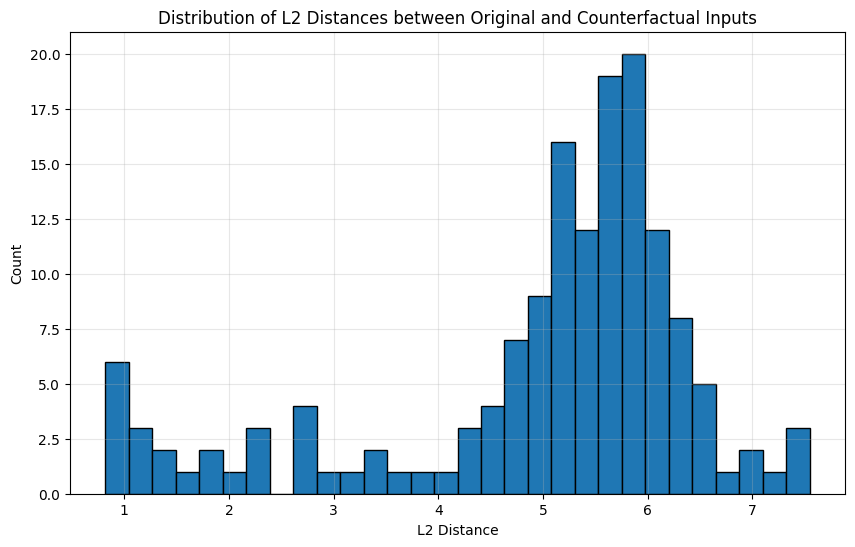

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(l2_distances, bins=30, edgecolor='black')
plt.xlabel('L2 Distance')
plt.ylabel('Count')
plt.title('Distribution of L2 Distances between Original and Counterfactual Inputs')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
def filter_by_l2_percentile(cfs, percentile=75):
    all_distances = []
    for idx, obj in cfs.items():
        clean_input = obj["clean"][0]
        cf_input = obj["cf"][0]
        l2_dist = np.linalg.norm(cf_input - clean_input)
        all_distances.append((idx, l2_dist))

    distances_only = [d for _, d in all_distances]
    threshold = np.percentile(distances_only, percentile)

    print(f"Using {percentile}th percentile threshold: {threshold:.4f}")

    filtered_cfs = {}
    kept_distances = []
    removed_count = 0

    for idx, obj in cfs.items():
        clean_input = obj["clean"][0]
        cf_input = obj["cf"][0]
        l2_dist = np.linalg.norm(cf_input - clean_input)

        if l2_dist <= threshold:
            filtered_cfs[idx] = obj
            kept_distances.append(l2_dist)
        else:
            removed_count += 1

    kept_distances = np.array(kept_distances)

    print(f"Kept {len(filtered_cfs)} counterfactuals")
    print(f"Removed {removed_count} counterfactuals")
    if len(kept_distances) > 0:
        print(f"Kept distances - mean: {kept_distances.mean():.4f}, "
              f"min: {kept_distances.min():.4f}, max: {kept_distances.max():.4f}")

    return filtered_cfs, threshold, kept_distances

# Usage:
cfs, threshold, kept_l2s = filter_by_l2_percentile(orig_cfs, percentile=75)

Using 75th percentile threshold: 5.8975
Kept 113 counterfactuals
Removed 38 counterfactuals
Kept distances - mean: 4.4861, min: 0.8184, max: 5.8959


In [10]:
model

Classifier(
  (stack): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): ReLU()
  )
  (head): Linear(in_features=64, out_features=4, bias=True)
)

In [11]:
# Set up a hook in the model so we can test if our linear approximation holds
# L(logits_clean_with_intervention) ~= L(logits_clean) + gradient_wrt_clean_logits * (activations_corrupted - activations_clean)

from typing import List, Callable
from contextlib import contextmanager

@contextmanager
def apply_fwd_hooks(module: nn.Module, *hooks: Callable[..., None]):
    handles = []
    for hook in hooks:
        handles.append(module.register_forward_hook(hook))
    yield
    for handle in handles:
        handle.remove()

def maybe_totensor(x, dtype):
    if isinstance(x, torch.Tensor):
            return x.to(torch.float32)
    return torch.from_numpy(x).cuda().to(dtype)

def intervened_act_run(x, cf, clone=True):
    act_cache = {}
    x, cf = maybe_totensor(x, torch.float32), maybe_totensor(cf, torch.float32)

    def get_act_to_patch(module, input, output):
        act_cache['cf'] = (output.clone() if clone else output)  # Use string keys

    def patch_act(module, input, output):
        act_cache['x'] = output.clone() if clone else output
        return act_cache['cf'].clone()  # Return the CF activation

    # Do a run with cf to collect act to patch
    with apply_fwd_hooks(INTERVENE_MODULE, get_act_to_patch):
        model(cf)

    # Patch and run with x
    with apply_fwd_hooks(INTERVENE_MODULE, patch_act):
        intervened_logits = model(x)

    clean_logits = model(x)

    # print(f"x.shape: {x.shape}")
    # print(f"cf.shape: {cf.shape}")
    # print(f"act_cache['x'].shape: {act_cache['x'].shape}")
    # print(f"act_cache['cf'].shape: {act_cache['cf'].shape}")

    return (intervened_logits, clean_logits), (act_cache['cf'], act_cache['x'])

In [12]:
idx = next(iter(cfs.keys()))
(i,c), _ = intervened_act_run(cfs[idx]["clean"][0], cfs[idx]["cf"][0])

intervened, clean = i[0].argmax().item(), c[0].argmax().item()
print(f"{intervened=}, {clean=}")

intervened=0, clean=0


In [13]:
# dataloader for attribution computation
from torch.utils.data import TensorDataset, StackDataset

cf_indices = []
X_cf_exp, y_cf_exp = [], []

for idx, obj in cfs.items():
    if obj["cf"] is not None:
        cf_indices.append(idx)
        X_cf_exp.append(obj["cf"][0])
        y_cf_exp.append(obj["cf"][1])

X_cf_exp = np.vstack(X_cf_exp)
y_cf_exp = np.array(y_cf_exp)

cf_indices = torch.tensor(cf_indices)

ds = TensorDataset(
    torch.from_numpy(X_exp[cf_indices]), torch.from_numpy(y_exp[cf_indices]), torch.from_numpy(X_cf_exp), torch.from_numpy(y_cf_exp),
)

acts_clean, acts_cf, all_intervened_logits = [], [], []

for batch in iter(DataLoader(ds, batch_size=128)):
    (intervened_logits, _), (act_clean, act_cf) = intervened_act_run(batch[0].cuda(), batch[2].cuda())

    # print(batch[0].shape, intervened_logits.shape, act_clean.shape, act_cf.shape)

    acts_clean.extend(act_clean)
    acts_cf.extend(act_cf)
    all_intervened_logits.extend(intervened_logits)

# print(len(ds), len(acts_clean), len(acts_cf), len(all_intervened_logits))

ds = StackDataset(
    ds, TensorDataset(
       torch.stack(acts_clean), torch.stack(acts_cf), torch.stack(all_intervened_logits)
    )
)

Does our approximation actually work?

In [22]:
dl = DataLoader(
    ds, batch_size=32
)

def logit_metric(logits, correct):
    return (logits.gather(-1, correct.unsqueeze(-1)) - logits).sum(-1)

def cuda(x):
    if isinstance(x, torch.Tensor):
        return x.cuda()
    return tuple(cuda(item) for item in x)

def compute_attribution(model, dl):
    total_err = 0
    examples = 0
    correct = 0
    other_choice_total_logit_err = 0

    pbar = tqdm(dl)

    for batch in pbar:
        # retrieve activation at layer
        (x,y,x_cf,y_cf),(_,act_cf,intervened_logits) = cuda(batch)

        # use hook to collect clean activation
        act_clean = None
        def _hook(m,i,o):
            nonlocal act_clean
            act_clean = o
        handle = INTERVENE_MODULE.register_forward_hook(_hook)
        logits = model(x.to(torch.float32))
        handle.remove()
        assert act_clean is not None

        act_clean.retain_grad()

        metric = logit_metric(logits, y.long().cuda()).mean()
        metric.backward()

        with torch.no_grad():
            approx = logit_metric(logits, y) + (act_clean.grad * (act_cf - act_clean)).sum(-1)

        # compute err wrt intervened logits on the correct true class
        # not counterfactual
        err = torch.norm(approx - logit_metric(intervened_logits, y), p=2, dim=-1).mean().item()

        # all_logits - correct_logits

        other_intervened = intervened_logits - intervened_logits.gather(-1, y_cf.unsqueeze(-1))
        other_clean = logits - logits.gather(-1,y.unsqueeze(-1))

        other_choice_total_logit_err += torch.norm(other_intervened - other_clean, dim=-1).mean()

        batch_size = x.shape[0]
        total_err += err
        examples += batch_size

        approx_logits = logits.scatter(-1, y_cf.unsqueeze(-1), approx.unsqueeze(-1))
        approx_pred = approx_logits.argmax(-1)
        correct += (approx_pred == y_cf).sum().item()
        # pbar.set_description(f"err={err:.4f} | acc={correct/examples:.3f}")

    print(f"\navg_tot_logit_err={(total_err / examples):.4f} | avg_other_logit_err={(other_choice_total_logit_err / examples):.4f} | acc={correct/examples:.4f} | {examples=}")

compute_attribution(model, DataLoader(
    ds, batch_size=16
))

100%|██████████| 8/8 [00:00<00:00, 351.58it/s]


avg_tot_logit_err=2.2479 | avg_other_logit_err=0.4586 | acc=0.9292 | examples=113


logit metric is $L(\ell)=\sum_{o\in O}\left(\ell[c]-\ell[o]\right)$, $O$ is the set of other answer choices.
$$L(\ell_\mathrm{int}) \approx L(\ell) + \nabla_L(a_\mathrm{int}-a)$$

expand

$$
\sum_{o\in O}\left(\ell_\mathrm{int}[c]-\ell_\mathrm{int}[o]\right)=
\sum_{o\in O}\left(\ell[c]-\ell[o]\right) +
(a_\mathrm{int}-a)^T\nabla_{a}L(\ell)
$$

Reasonable to assume that $\|\ell_\mathrm{int}[o]-\ell[o]\|$ is quite small. This means we are only boosting prob. mass onto the correct answer choice.

This means the `avg_other_logit_err` should pretty small compared to `avg_tot_logit_err`.